### EDA - healthcare claims and insurance cost analysis

In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
claims = pd.read_csv('datasets/healthcare_claims_clean.csv') 
claims.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,...,Discharge Date,Medication,Test Results,Claim ID,Length of Stay,Age Group,Cost Category,Claim Status,Reimbursement Amount,Patient Payable
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,...,2024-02-02,Paracetamol,Normal,CLM000001,2,19-35,Medium,Approved,16588.82,2267.46
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,...,2019-08-26,Ibuprofen,Inconclusive,CLM000002,6,51-65,Medium,Pending,19478.92,14164.41
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,...,2022-10-07,Aspirin,Normal,CLM000003,15,65+,Medium,Approved,25696.08,2259.02
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,...,2020-12-18,Ibuprofen,Abnormal,CLM000004,30,19-35,High,Approved,30650.29,7259.49
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,...,2022-10-09,Penicillin,Abnormal,CLM000005,20,36-50,Low,Approved,11410.65,2827.67


##### Executive KPI's

In [3]:
total_claims = len(claims) 
total_billing = claims['Billing Amount'].sum()
avg_claim = claims['Billing Amount'].mean() 
total_reimbursement = claims['Reimbursement Amount'].sum() 
avg_los = claims['Length of Stay'].mean() 
approval_rate = ( (claims['Claim Status'] == 'Approved').mean() * 100 ) 
denial_rate = ( (claims['Claim Status'] == 'Denied').mean() * 100 ) 
pending_rate = ( (claims['Claim Status'] == 'Pending').mean() * 100 ) 

print(f'Total Claims: {total_claims:,}') 
print(f'Total Billing: ${total_billing:,.0f}') 
print(f'Average Claim: ${avg_claim:,.2f}') 
print(f'Total Reimbursement: ${total_reimbursement:,.0f}') 
print(f'Average Length of Stay: {avg_los:.1f} days') 
print(f'Approval Rate: {approval_rate:.1f}%') 
print(f'Denial Rate: {denial_rate:.1f}%') 
print(f'Pending Rate: {pending_rate:.1f}%')

Total Claims: 54,860
Total Billing: $1,404,121,601
Average Claim: $25,594.63
Total Reimbursement: $1,038,068,658
Average Length of Stay: 15.5 days
Approval Rate: 78.2%
Denial Rate: 11.9%
Pending Rate: 10.0%


##### Claim by Status

In [4]:
status_counts = claims['Claim Status'].value_counts()

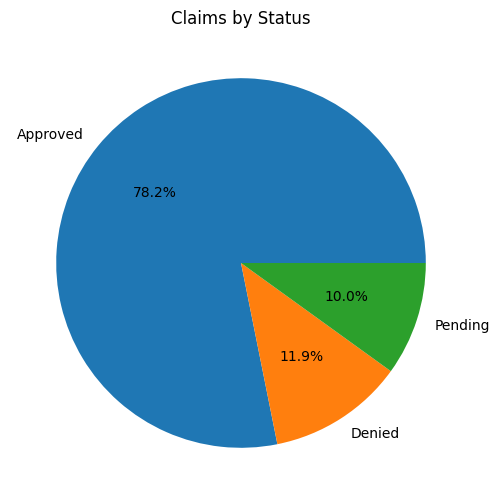

In [5]:
plt.figure(figsize=(6,6)) 
plt.pie(status_counts.values, labels=status_counts.index, autopct='%1.1f%%') 
plt.title('Claims by Status') 
plt.show()

##### Cost by Insurance Provider

In [10]:
insurance_cost = claims.groupby('Insurance Provider')['Billing Amount'].mean().sort_values(ascending=False) 
insurance_cost

Insurance Provider
Medicare            25678.087847
Blue Cross          25639.269835
Aetna               25615.260975
Cigna               25582.227724
UnitedHealthcare    25458.893302
Name: Billing Amount, dtype: float64

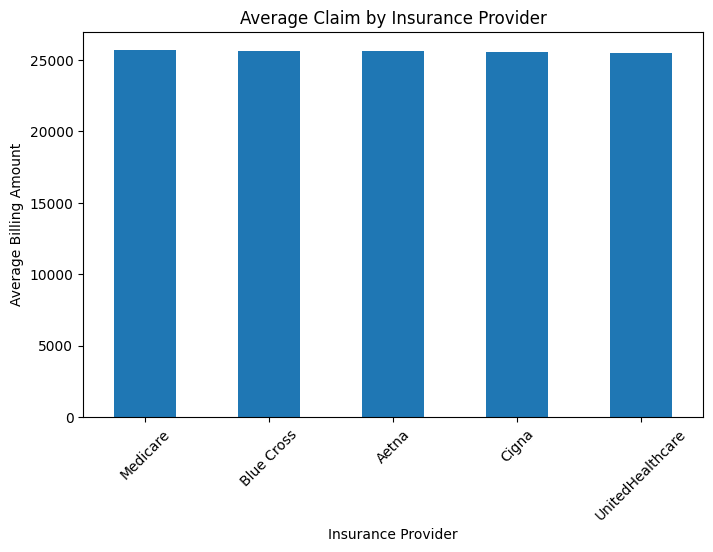

In [13]:
plt.figure(figsize=(8,5)) 
insurance_cost.plot(kind='bar') 
plt.ylabel('Average Billing Amount') 
plt.title('Average Claim by Insurance Provider') 
plt.xticks(rotation=45) 
plt.show()

#####  Top Medical Conditions by Total Cost

In [14]:
condition_cost = claims.groupby('Medical Condition')['Billing Amount'].sum().sort_values(ascending=False) 
condition_cost

Medical Condition
Diabetes        2.364947e+08
Obesity         2.360171e+08
Arthritis       2.351735e+08
Hypertension    2.333869e+08
Asthma          2.331462e+08
Cancer          2.299032e+08
Name: Billing Amount, dtype: float64

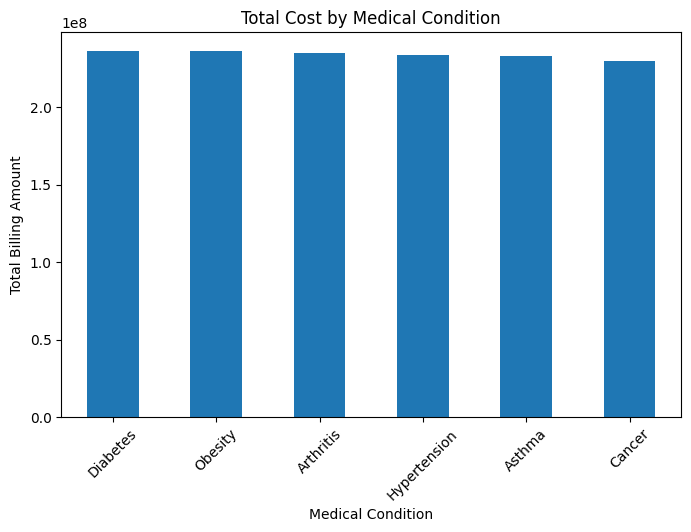

In [15]:
plt.figure(figsize=(8,5)) 
condition_cost.plot(kind='bar') 
plt.ylabel('Total Billing Amount') 
plt.title('Total Cost by Medical Condition') 
plt.xticks(rotation=45) 
plt.show()

##### Age Group vs Cost

In [16]:
age_cost=claims.groupby('Age Group')['Billing Amount'].mean()
age_cost

Age Group
0-18     26776.603299
19-35    25573.689035
36-50    25564.299710
51-65    25708.895819
65+      25482.710612
Name: Billing Amount, dtype: float64

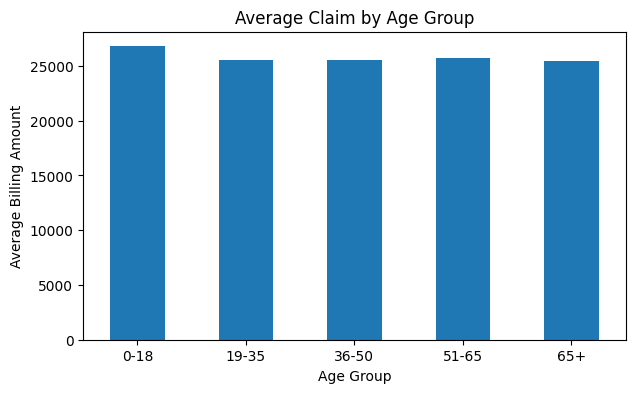

In [17]:
plt.figure(figsize=(7,4))
age_cost.plot(kind='bar')
plt.ylabel('Average Billing Amount')
plt.title('Average Claim by Age Group')
plt.xticks(rotation=0)
plt.show()

##### Admission Type vs Cost

In [19]:
admission_cost = claims.groupby('Admission Type')['Billing Amount'].mean().sort_values(ascending=False)
admission_cost

Admission Type
Elective     25663.342261
Urgent       25568.439653
Emergency    25551.133763
Name: Billing Amount, dtype: float64

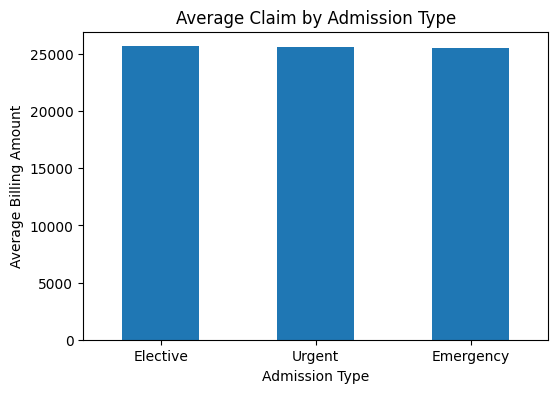

In [20]:
plt.figure(figsize=(6,4)) 
admission_cost.plot(kind='bar') 
plt.ylabel('Average Billing Amount') 
plt.title('Average Claim by Admission Type') 
plt.xticks(rotation=0) 
plt.show()

##### Length of Stay vs Billing

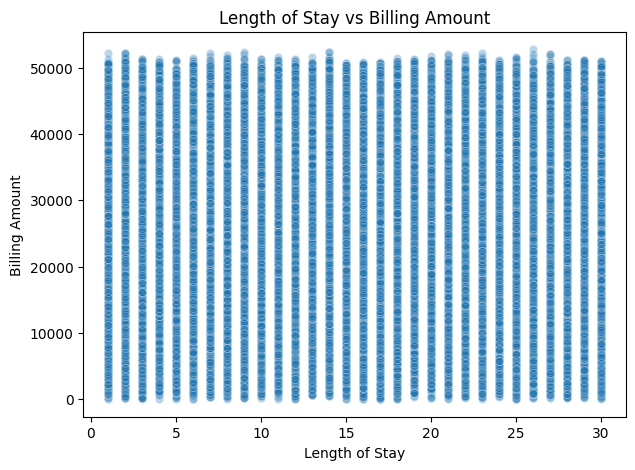

In [21]:
plt.figure(figsize=(7,5)) 
sns.scatterplot(data=claims, x='Length of Stay', y='Billing Amount', alpha=0.3) 
plt.title('Length of Stay vs Billing Amount') 
plt.show()

##### Distribution of Billing Amounts

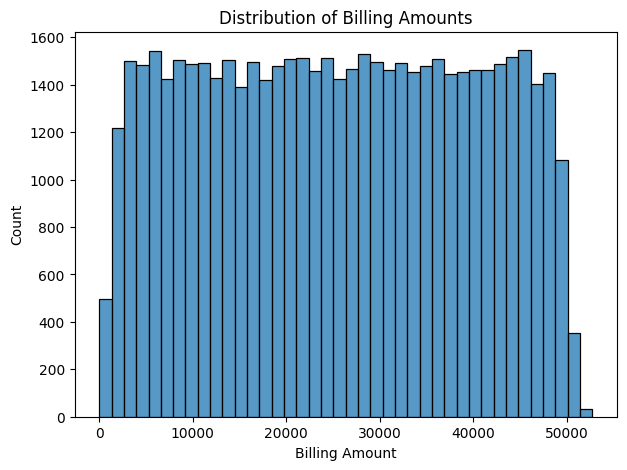

In [22]:
plt.figure(figsize=(7,5)) 
sns.histplot(claims['Billing Amount'], bins=40) 
plt.title('Distribution of Billing Amounts') 
plt.show()

##### Top 10 Hospitals by Total Billing

In [23]:
top_hospitals = claims.groupby('Hospital')['Billing Amount'].sum().sort_values(ascending=False).head(10)

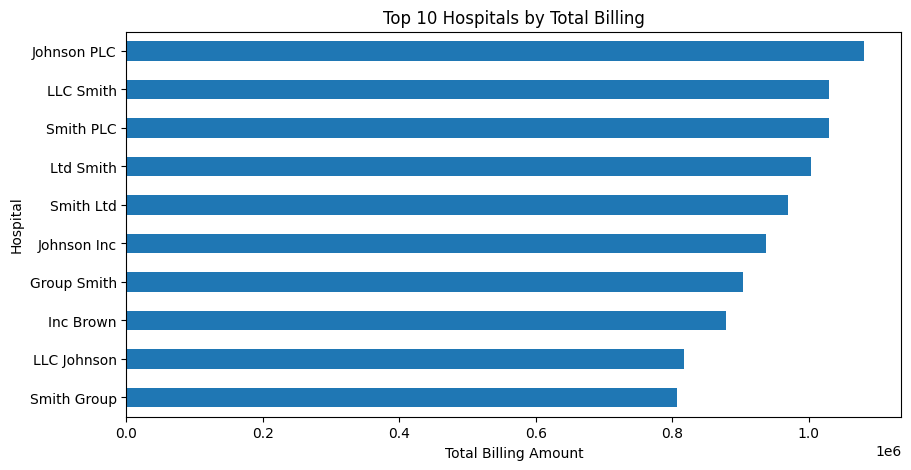

In [24]:
plt.figure(figsize=(10,5)) 
top_hospitals.sort_values().plot(kind='barh') 
plt.xlabel('Total Billing Amount') 
plt.title('Top 10 Hospitals by Total Billing') 
plt.show()

##### Reimbursement vs Patient Payable

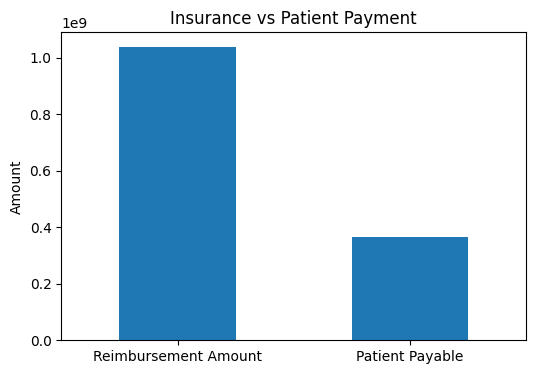

In [25]:
summary = claims[['Reimbursement Amount', 'Patient Payable']].sum() 
plt.figure(figsize=(6,4)) 
summary.plot(kind='bar') 
plt.ylabel('Amount') 
plt.title('Insurance vs Patient Payment') 
plt.xticks(rotation=0) 
plt.show()